In [28]:
import pandas as pd

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

In [29]:
df = pd.read_excel('zepto_v1.xlsx')

In [30]:
print(df.shape)

(3732, 9)


In [31]:
print(df.head())

              Category              name   mrp  discountPercent  \
0  Fruits & Vegetables             Onion  2500               16   
1  Fruits & Vegetables     Tomato Hybrid  4200               16   
2  Fruits & Vegetables    Tender Coconut  5100               15   
3  Fruits & Vegetables  Coriander Leaves  2000               15   
4  Fruits & Vegetables    Ladies Finger   1400               14   

   availableQuantity  discountedSellingPrice  weightInGms  outOfStock  \
0                  3                    2100         1000       False   
1                  3                    3500         1000       False   
2                  3                    4300           58       False   
3                  3                    1700          100       False   
4                  3                    1200          250       False   

   quantity  
0         1  
1         1  
2         1  
3       100  
4       250  


In [32]:
print(df.dtypes)

Category                  object
name                      object
mrp                        int64
discountPercent            int64
availableQuantity          int64
discountedSellingPrice     int64
weightInGms                int64
outOfStock                  bool
quantity                   int64
dtype: object


In [33]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Category                3732 non-null   object
 1   name                    3732 non-null   object
 2   mrp                     3732 non-null   int64 
 3   discountPercent         3732 non-null   int64 
 4   availableQuantity       3732 non-null   int64 
 5   discountedSellingPrice  3732 non-null   int64 
 6   weightInGms             3732 non-null   int64 
 7   outOfStock              3732 non-null   bool  
 8   quantity                3732 non-null   int64 
dtypes: bool(1), int64(6), object(2)
memory usage: 237.0+ KB
None


In [34]:
print(df.isnull().sum())

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64


In [35]:
print(df.isnull().mean() * 100)

Category                  0.0
name                      0.0
mrp                       0.0
discountPercent           0.0
availableQuantity         0.0
discountedSellingPrice    0.0
weightInGms               0.0
outOfStock                0.0
quantity                  0.0
dtype: float64


In [36]:
print(df.duplicated().sum())

2


In [37]:
df = df.drop_duplicates()

In [38]:
df['outOfStock'] = df['outOfStock'].astype(bool)

In [39]:
df['mrp'] = df['mrp'] / 100
df['discountedSellingPrice'] = df['discountedSellingPrice'] / 100

In [40]:
print(df[df['mrp'] == 0])

             Category                                        name  mrp  \
3606  Home & Cleaning  Cherry Blossom Liquid Shoe Polish Neutral   0.0   

      discountPercent  availableQuantity  discountedSellingPrice  weightInGms  \
3606                0                  1                     0.0           75   

      outOfStock  quantity  
3606       False        75  


In [41]:
df = df[df['mrp'] > 0]

In [42]:
print(df[df['discountedSellingPrice'] > df['mrp']])

Empty DataFrame
Columns: [Category, name, mrp, discountPercent, availableQuantity, discountedSellingPrice, weightInGms, outOfStock, quantity]
Index: []


In [43]:
print(df[(df['availableQuantity'] == 0) & (df['outOfStock'] == False)])

Empty DataFrame
Columns: [Category, name, mrp, discountPercent, availableQuantity, discountedSellingPrice, weightInGms, outOfStock, quantity]
Index: []


In [44]:
df['calc_discount'] = ((df['mrp'] - df['discountedSellingPrice']) / df['mrp'] * 100).round(1)

In [45]:
df['discount_mismatch'] = abs(df['calc_discount'] - df['discountPercent']) > 2

In [46]:
print(df['discount_mismatch'].sum(), "rows with discount mismatch")

0 rows with discount mismatch


In [47]:
print(df.describe())

               mrp  discountPercent  availableQuantity  \
count  3729.000000      3729.000000        3729.000000   
mean    156.846876         7.617860           4.008313   
std     160.932226         9.214429           2.203364   
min      10.000000         0.000000           0.000000   
25%      60.000000         0.000000           2.000000   
50%     110.000000         6.000000           5.000000   
75%     200.000000        10.000000           6.000000   
max    2600.000000        51.000000           6.000000   

       discountedSellingPrice   weightInGms     quantity  calc_discount  
count             3729.000000   3729.000000  3729.000000    3729.000000  
mean               141.970126    388.001609   213.288281       7.862161  
std                138.543383    678.342411   194.794291       9.269882  
min                  9.000000      0.000000     0.000000       0.000000  
25%                 55.000000    100.000000    50.000000       0.000000  
50%                104.000000    

In [48]:
print(df.groupby('Category')['outOfStock'].mean().sort_values(ascending=False).round(3))

Category
Biscuits                 0.286
Beverages                0.217
Dairy, Bread & Batter    0.217
Meats, Fish & Eggs       0.190
Health & Hygiene         0.134
Cooking Essentials       0.125
Munchies                 0.125
Chocolates & Candies     0.116
Packaged Food            0.116
Ice Cream & Desserts     0.116
Home & Cleaning          0.098
Fruits & Vegetables      0.065
Paan Corner              0.061
Personal Care            0.061
Name: outOfStock, dtype: float64


In [49]:
df = df[df['mrp'] > 0]
print(df.shape)

(3729, 11)


In [50]:
df['revenue_exposure'] = df.apply(
    lambda row: row['discountedSellingPrice'] if row['outOfStock'] else 0, axis=1
)

print(df['revenue_exposure'].sum())

39018.5


In [67]:
category_analysis = df.groupby('Category').agg(
    total_skus=('name', 'count'),
    oos_skus=('outOfStock', 'sum'),
    stockout_rate=('outOfStock', 'mean'),
    revenue_exposure=('revenue_exposure', 'sum'),
    avg_mrp=('mrp', 'mean')
).round(2)
category_analysis['stockout_rate'] = (category_analysis['stockout_rate'] * 100).round(1)
category_analysis = category_analysis.sort_values('revenue_exposure', ascending=False)
print(category_analysis)

                       total_skus  oos_skus  stockout_rate  revenue_exposure  \
Category                                                                       
Cooking Essentials            514        64           12.0            5830.0   
Munchies                      514        64           12.0            5830.0   
Ice Cream & Desserts          388        45           12.0            3974.0   
Packaged Food                 388        45           12.0            3974.0   
Chocolates & Candies          388        45           12.0            3974.0   
Paan Corner                   343        21            6.0            2385.0   
Personal Care                 343        21            6.0            2385.0   
Meats, Fish & Eggs             63        12           19.0            2024.0   
Beverages                     129        28           22.0            1949.0   
Dairy, Bread & Batter         129        28           22.0            1949.0   
Home & Cleaning               193       

In [56]:
df['mrp_normalized'] = (df['mrp'] - df['mrp'].min()) / (df['mrp'].max() - df['mrp'].min())

In [57]:
category_oos_rate = df.groupby('Category')['outOfStock'].mean()
df['category_oos_rate'] = df['Category'].map(category_oos_rate)

In [58]:
df['priority_score'] = (
    (df['outOfStock'].astype(int) * 3) +
    (df['mrp_normalized'] * 2) +
    (df['category_oos_rate'] * 1)
).round(3)

In [68]:
def assign_tier(score):
    if score >= 3.3:
        return 'High'
    elif score >= 1.0:
        return 'Medium'
    else:
        return 'Low'

df['priority_tier'] = df['priority_score'].apply(assign_tier)

In [69]:
print(df['priority_tier'].value_counts())

priority_tier
Low       3264
Medium     405
High        60
Name: count, dtype: int64


In [70]:
top_priority = df[df['outOfStock'] == True].sort_values('priority_score', ascending=False)
print(top_priority[['Category', 'name', 'mrp', 'discountPercent', 'priority_score', 'priority_tier']].head(20))

                   Category  \
580      Cooking Essentials   
1094               Munchies   
2744               Biscuits   
1378              Beverages   
1249  Dairy, Bread & Batter   
2599     Meats, Fish & Eggs   
2721               Biscuits   
2605     Meats, Fish & Eggs   
2602     Meats, Fish & Eggs   
2603     Meats, Fish & Eggs   
3096          Personal Care   
3440            Paan Corner   
1067               Munchies   
553      Cooking Essentials   
2748               Biscuits   
1087               Munchies   
573      Cooking Essentials   
1369              Beverages   
1240  Dairy, Bread & Batter   
2598     Meats, Fish & Eggs   

                                                   name    mrp  \
580                                Patanjali Cow's Ghee  565.0   
1094                               Patanjali Cow's Ghee  565.0   
2744                  Britannia Good Day Cashew Cookies  230.0   
1378                        RRO Mozzarella Block Cheese  295.0   
1249              

In [71]:
tier_summary = df.groupby('priority_tier').agg(
    sku_count=('name', 'count'),
    avg_mrp=('mrp', 'mean'),
    revenue_exposure=('revenue_exposure', 'sum')
).round(2)
print(tier_summary)

               sku_count  avg_mrp  revenue_exposure
priority_tier                                      
High                  60   189.75           10349.0
Low                 3264   160.62               0.0
Medium               405   121.55           28669.5


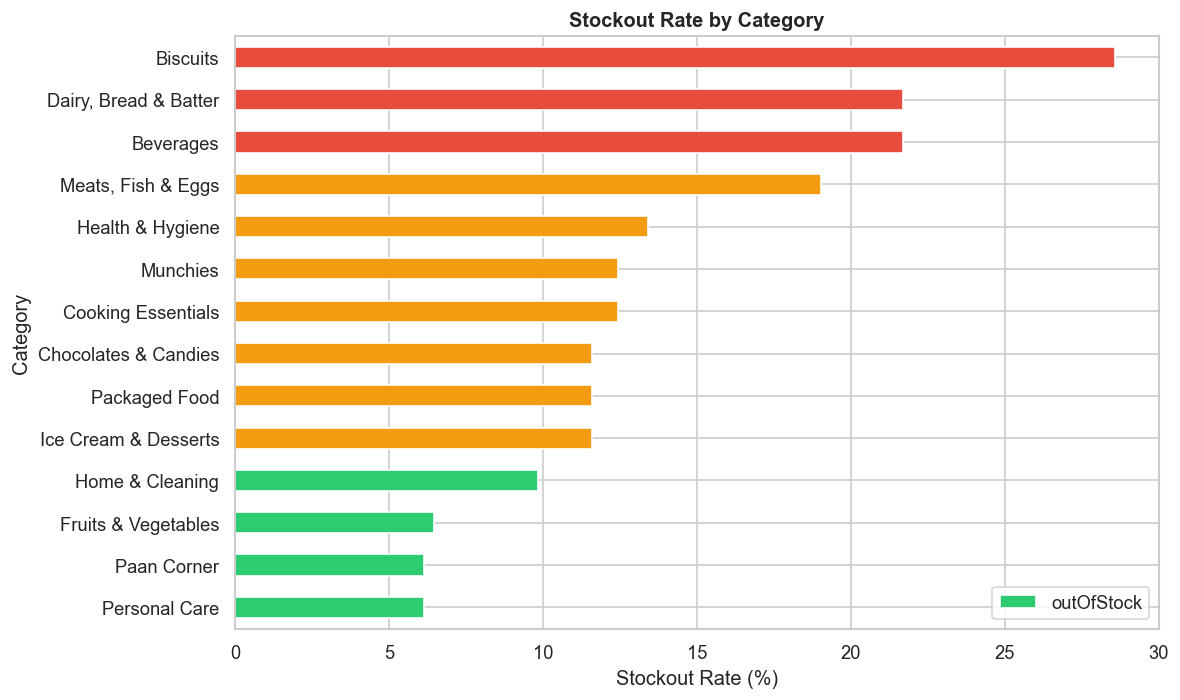

In [79]:
fig, ax = plt.subplots(figsize=(10, 6))

stockout_by_cat = df.groupby('Category')['outOfStock'].mean().sort_values() * 100

colors = ['#e74c3c' if x >= 20 else '#f39c12' if x >= 10 else '#2ecc71' 
          for x in stockout_by_cat]

stockout_by_cat.plot(kind='barh', ax=ax, color=colors)

ax.set_xlabel('Stockout Rate (%)')
ax.set_title('Stockout Rate by Category', fontweight='bold')
ax.legend(handles=[plt.Line2D([0], [0], color='navy', linestyle='--')],
          labels=[f'Average ({stockout_by_cat.mean():.1f}%)'])
ax.legend()

plt.tight_layout()
plt.savefig('chart1_stockout_rate.png')
plt.show()

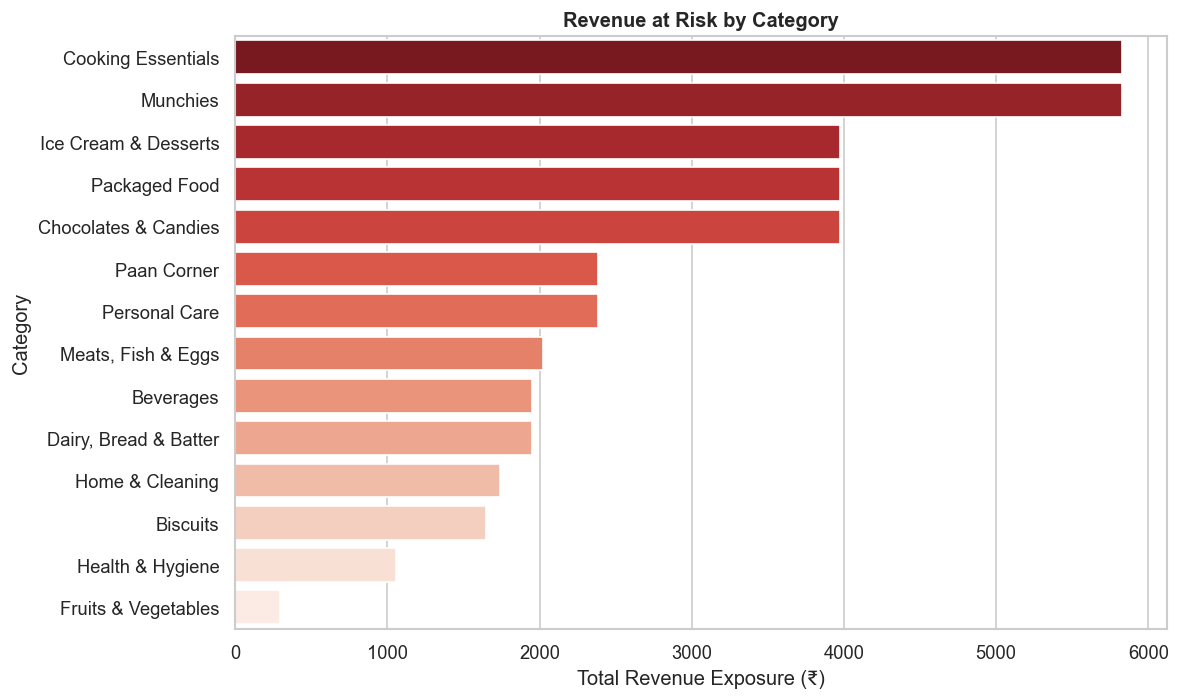

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))

rev_by_cat = df.groupby('Category')['revenue_exposure'].sum().sort_values(ascending=False)

sns.barplot(x=rev_by_cat.values, y=rev_by_cat.index, 
            hue=rev_by_cat.index, palette='Reds_r', ax=ax, legend=False)

ax.set_xlabel('Total Revenue Exposure (₹)')
ax.set_title('Revenue at Risk by Category', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_revenue_exposure.png')
plt.show()

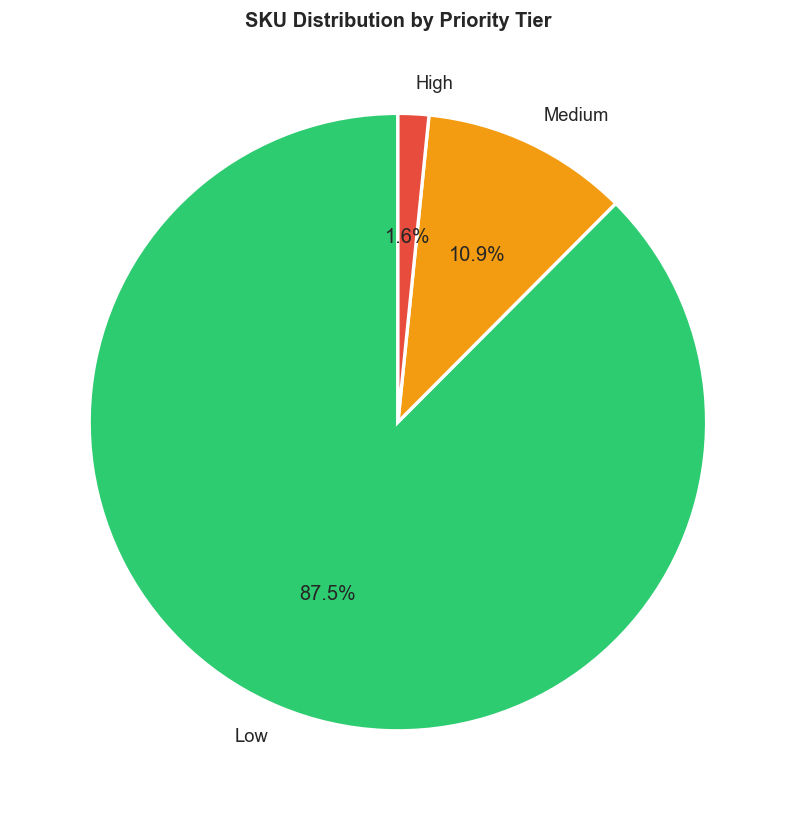

In [75]:
fig, ax = plt.subplots(figsize=(7, 7))

tier_counts = df['priority_tier'].value_counts()
colors_pie = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}

ax.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=[colors_pie[t] for t in tier_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax.set_title('SKU Distribution by Priority Tier', fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_priority_tiers.png')
plt.show()

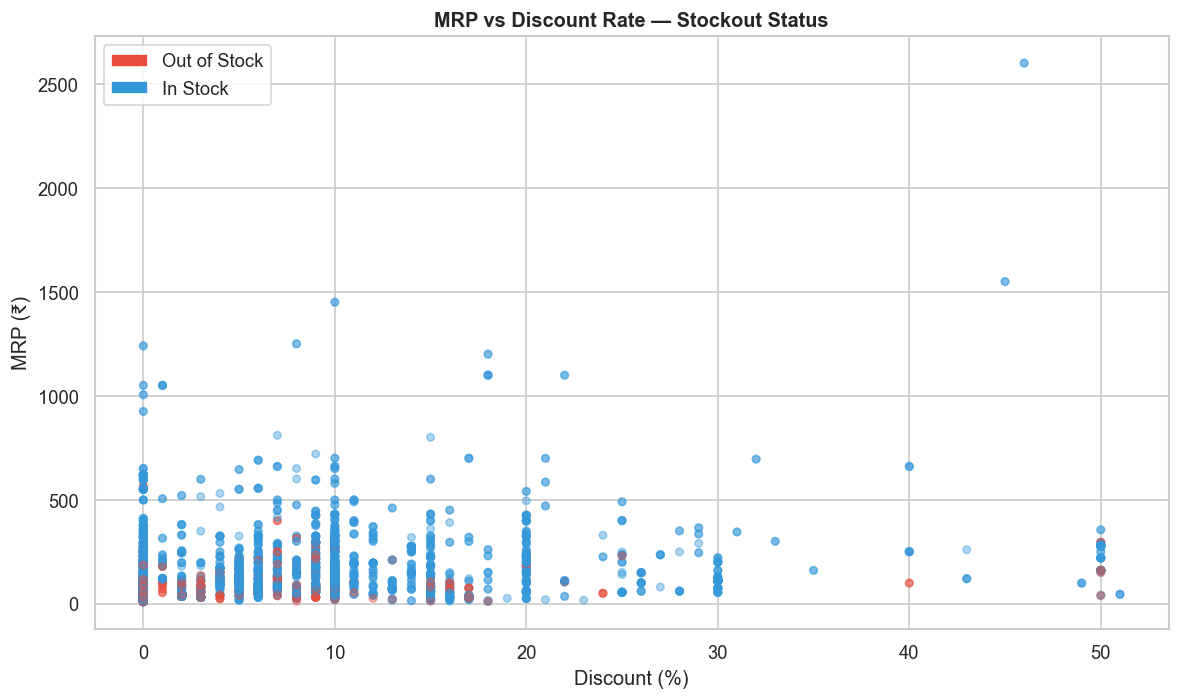

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_scatter = df['outOfStock'].map({True: '#e74c3c', False: '#3498db'})

ax.scatter(df['discountPercent'], df['mrp'], 
           c=colors_scatter, alpha=0.4, s=20)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Out of Stock'),
                   Patch(facecolor='#3498db', label='In Stock')]
ax.legend(handles=legend_elements)

ax.set_xlabel('Discount (%)')
ax.set_ylabel('MRP (₹)')
ax.set_title('MRP vs Discount Rate — Stockout Status', fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_mrp_vs_discount.png')
plt.show()

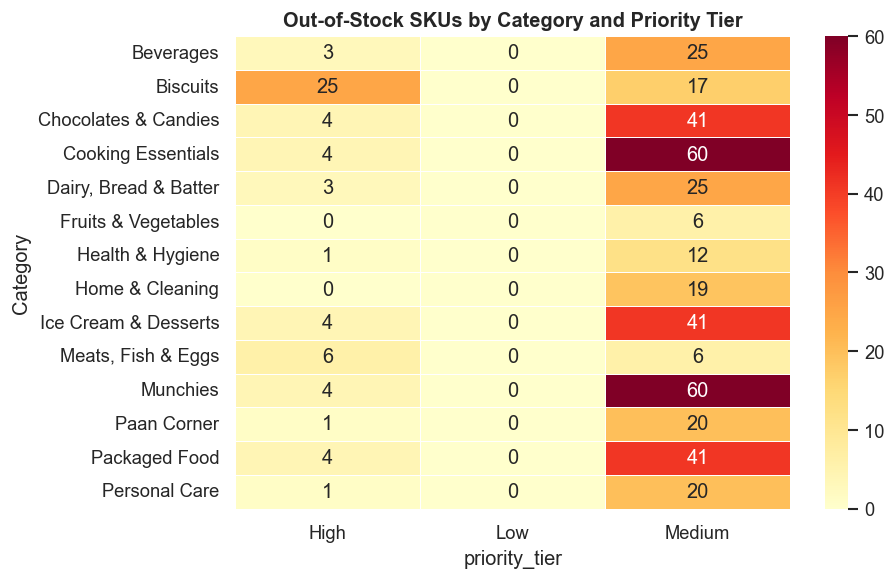

In [77]:
fig, ax = plt.subplots(figsize=(8, 5))

heatmap_data = df.groupby(['Category', 'priority_tier'])['outOfStock'].sum().unstack(fill_value=0)

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, ax=ax)

ax.set_title('Out-of-Stock SKUs by Category and Priority Tier', fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_heatmap.png')
plt.show()

In [78]:
df.to_csv('zepto_analysis_final.csv', index=False)
print("File saved!")

File saved!
